# 超全面讲透一个统计检验方法，卡方检验！！
https://mp.weixin.qq.com/s/c8ztLpar4NBsEjbUe2Td-A

先说：什么是“统计检验”？

统计检验就是用数据来“检验”一个说法是不是成立。

打个比方：
你怀疑一枚硬币**不是**公平的（不一定是正反各一半），那你就收集若干次投掷结果，用统计检验看数据有没有足够证据反驳“硬币是公平的”这个说法。

流程很简单：
1. 先提出**无效假设（H₀）**（通常是“没差别”或“没关系”）。
2. 提出**备择假设（H₁）**（你想证明的）。
3. **计算一个检验统计量**（从数据算出的一个数）。
4. 看这个数在对应的参考分布里处于什么位置（是不是很极端），或者看对应的 **p 值**。
5. 根据显著性水平（比如 0.05）决定**拒绝还是不拒绝 H₀**，最后用自然语言说明结论。

## 卡方检验（Chi-square test）是什么？
卡方检验是用来处理类别数据的：例如“男/女”“吸烟/不吸烟”“A/B/C 三个品牌”等。它用来检验两类问题里的“差别”或“关系”是否显著。

常见两种情形：
- **拟合优度检验**：检验观测到的类别频数，是否与某个理论（比如“均匀分布”或“厂家标称的比例”）一致。
- **独立性检验/列联表检验**：检验两个分类变量（比如 性别 和 是否吸烟）是否相互独立（没有关联）。

它的核心公式很简单：
χ² = Σ[(O - E)² / E]
其中，O = 观测到的次数（Observed），E = 在“没差别”的假设下预期的次数（Expected）

直观理解：每一格算一个 (O - E)² / E，把这些“偏差程度”加起来，就是 χ² 值，值越大表示观测和预期越不一致。

### 自由度（degrees of freedom, df）：
- 拟合优度：df = 类别数 k − 1（有时候还要减去估计参数个数）
- 独立性（r×c 表）：df = (行数−1) × (列数−1)

最后把 χ² 值和相应自由度对应的卡方分布比较，或算 p 值，决定显著性。

先来两个例子，大家便于理解：

#### 举例 1：掷 120 次骰子，想知道骰子是不是公平（拟合优度检验）
假设观察到的结果（每面点数出现次数）为：
- 1 点：8 次
- 2 点：20 次
- 3 点：22 次
- 4 点：18 次
- 5 点：26 次
- 6 点：26 次

总次数 = 120。理论上“公平骰子”每面期望次数 E = 120 / 6 = 20。

现在一步步代入公式计算 (O - E)² / E（按每一面算贡献）：
- 面 1：(8-20)² / 20 = 144 / 20 = 7.2
- 面 2：(20-20)² / 20 = 0 / 20 = 0
- 面 3：(22-20)² / 20 = 4 / 20 = 0.2
- 面 4：(18-20)² / 20 = 4 / 20 = 0.2
- 面 5：(26-20)² / 20 = 36 / 20 = 1.8
- 面 6：同面 5，贡献 1.8

把这些加起来：χ² = 7.2 + 0 + 0.2 + 0.2 + 1.8 + 1.8 = 11.2

自由度 df = 6 − 1 = 5。

接下来比对卡方分布或者查表/软件（我们常用显著性水平 α = 0.05）：
如果 χ² 比临界值大，说明观测与“公平”差别显著 → **拒绝 H₀（骰子不公平）**。在这个例子中 χ² = 11.2，稍微超过了 df=5 时 0.05 水平的临界值（大约 11.07），因此在 5% 显著性水平下我们会倾向于**认为骰子可能不是公平的**（但差别并不大，是“刚好”超过门槛）。

**重要小提醒**：这说明“有统计学证据不支持公平”，但要结合现实意义（是不是因为实验操作问题、样本量、还是偶然）来判断。

#### 举例 2：性别（男/女）和是否吸烟（吸烟/不吸烟）有没有关系？（列联表、独立性检验）
观测到的数据（总样本 200 人）：

|       | 吸烟 | 不吸烟 | 小计 |
|-------|------|--------|------|
| 男    | 30   | 70     | 100  |
| 女    | 20   | 80     | 100  |
| 小计  | 50   | 150    | 200  |

先算每格的期望次数 E =（行总 × 列总）/ 总样本：
- 男-吸烟：E=(100×50)/200 = 25
- 男-不吸烟：E=(100×150)/200 = 75
- 女-吸烟：E=(100×50)/200 = 25
- 女-不吸烟：E=(100×150)/200 = 75

逐格算 (O - E)² / E 贡献：
- 男-吸烟：(30-25)² / 25 = 25 / 25 = 1
- 男-不吸烟：(70-75)² / 75 = 25 / 75 ≈ 0.333...（即 1/3）
- 女-吸烟：(20-25)² / 25 = 25 / 25 = 1
- 女-不吸烟：(80-75)² / 75 = 25 / 75 ≈ 0.333...

加起来：χ² = 1 + 0.333... + 1 + 0.333... ≈ 2.666...（也就是8/3）

自由度 df = (2−1)×(2−1) = 1。

查表或比较临界值（df=1 时 α=0.05 的临界值约为 3.84），我们的 χ² = 2.67 小于 3.84，所以**不能拒绝独立性假设**：即**没有足够证据表明性别与吸烟有统计学上的关联**（换句话说，基于这份样本，性别和是否吸烟看起来是独立的）。

## 注意项
下面几个点，大家需要注意~
- **数据类型要对**：卡方检验只针对分类（类别）数据，不能直接用来比较两个平均数（那时用 t 检验/ANOVA）。
- **样本独立**：每个观测必须相互独立（比如不同人的回答），否则结果不可靠。
- **期望次数不能太小**：通常每个格子的期望 E 最好 ≥ 5。如果很多格子小于 5，卡方近似不好，应该合并类别或改用 Fisher 精确检验（针对 2×2 表）。
- **2×2 表有校正**：对于 2×2 表有时会用 Yates 校正，但现代做法通常直接用精确检验或统计软件给出的 p 值。
- **显著 ≠ 重要**：样本很大时，很小的差别也可能显著；要看效应大小（例如 Cramér’s V），不要只盯 p 值。

## 完整案例实现
某公司对 200 名消费者做了问卷调查，想分析「购买产品类型」与「消费者地区」是否有关。
- 产品类型：A、B、C
- 地区：东部、中部、西部、北部

公司想知道，不同地区的人购买产品的比例分布是不是一致，还是有显著差异。

我们将使用 卡方独立性检验 来检验“产品类型与地区是否独立”。

### 分析步骤
1. 构建一个 3×4 的列联表（虚拟数据）。
2. 计算期望值 E 并手动算出卡方统计量。
3. 基于自由度计算 p 值，并绘制卡方分布曲线，标记统计量位置。
4. 数据分析可视化，直观展示数据差异与分布。

观测值：
    东部  中部  西部  北部
A  25  30  20  15
B  15  25  30  10
C  10  20  25  25

期望值：
      东部    中部    西部    北部
A  18.0  27.0  27.0  18.0
B  16.0  24.0  24.0  16.0
C  16.0  24.0  24.0  16.0

χ² 统计量: 17.2454
自由度: 6
p 值: 0.0084


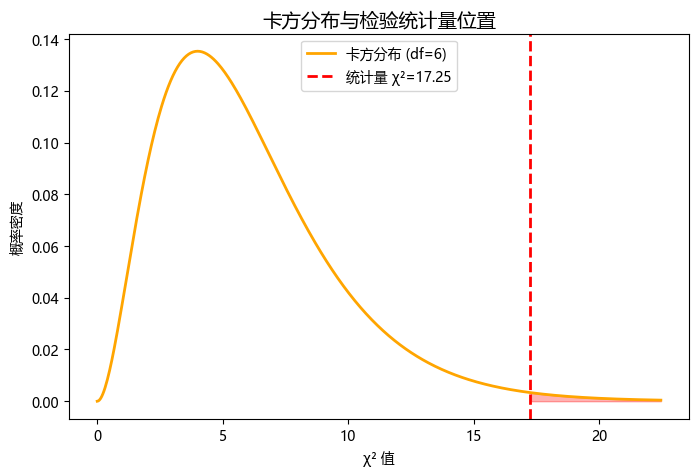

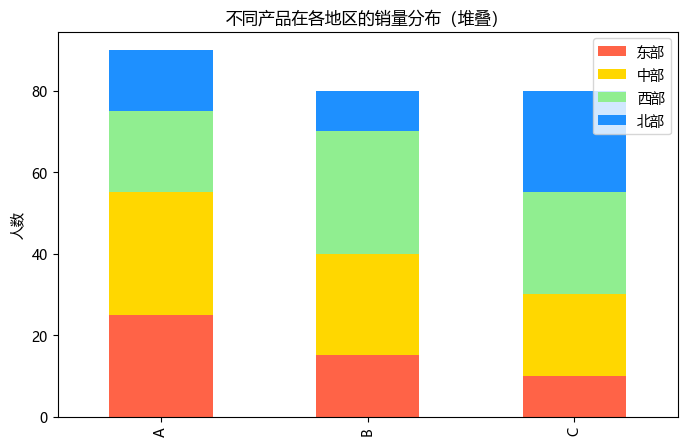

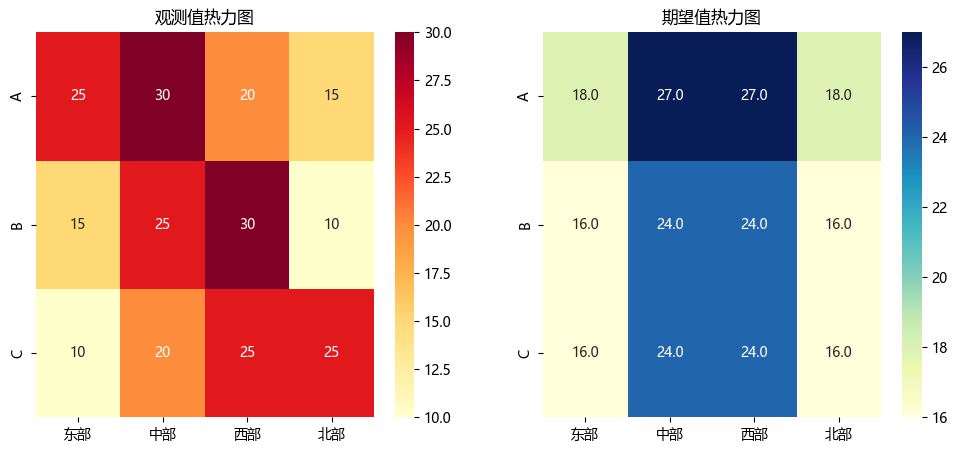

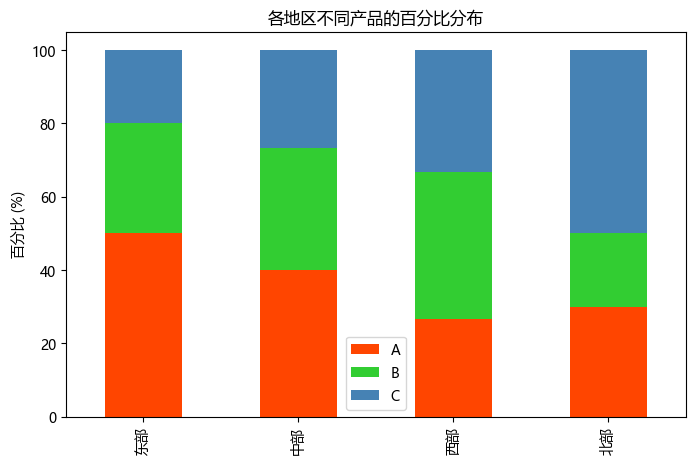

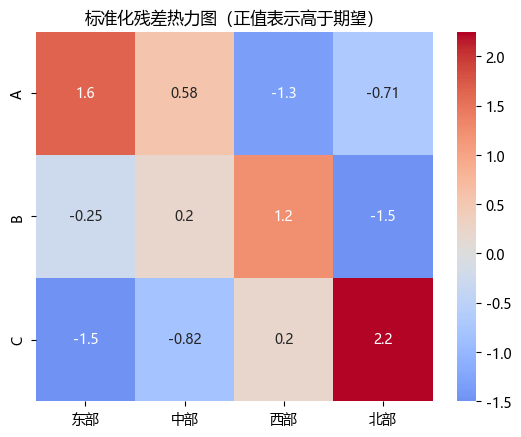

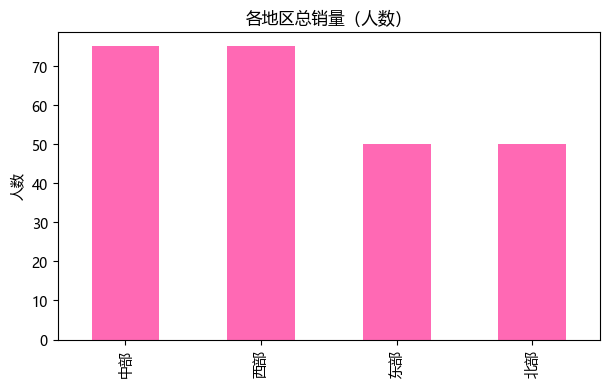

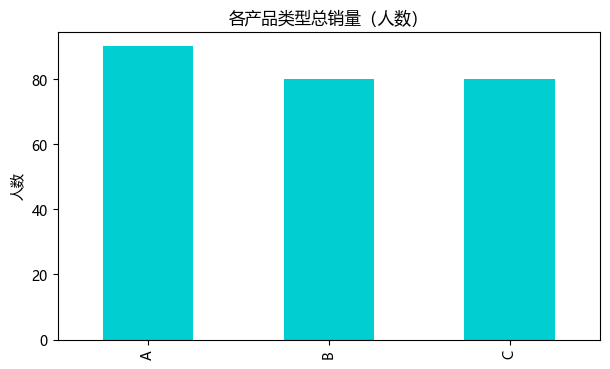

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

# 设置中文字体（如微软雅黑），确保中文正常显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 虚拟数据（3 产品类型 × 4 地区）
observed = np.array([
    [25, 30, 20, 15],  # 产品 A
    [15, 25, 30, 10],  # 产品 B
    [10, 20, 25, 25]   # 产品 C
])
products = ["A", "B", "C"]
regions = ["东部", "中部", "西部", "北部"]
df_obs = pd.DataFrame(observed, index=products, columns=regions)

# 2. 手动计算卡方统计量
total = observed.sum()
row_totals = observed.sum(axis=1).reshape(-1, 1)
col_totals = observed.sum(axis=0).reshape(1, -1)
expected = row_totals @ col_totals / total  # 外积计算 E

chi2_stat = ((observed - expected) ** 2 / expected).sum()
dfree = (observed.shape[0] - 1) * (observed.shape[1] - 1)
p_value = 1 - chi2.cdf(chi2_stat, dfree)

print("观测值：\n", df_obs)
print("\n期望值：\n", pd.DataFrame(expected, index=products, columns=regions))
print(f"\nχ² 统计量: {chi2_stat:.4f}")
print(f"自由度: {dfree}")
print(f"p 值: {p_value:.4f}")

# 3. 绘制卡方分布曲线并标记统计量位置
x = np.linspace(0, chi2.ppf(0.999, dfree), 500)
plt.figure(figsize=(8,5))
plt.plot(x, chi2.pdf(x, dfree), color="orange", lw=2, label=f"卡方分布 (df={dfree})")
plt.axvline(chi2_stat, color="red", linestyle="--", lw=2, label=f"统计量 χ²={chi2_stat:.2f}")
plt.fill_between(x, chi2.pdf(x, dfree), where=(x >= chi2_stat), color="red", alpha=0.3)
plt.title("卡方分布与检验统计量位置", fontsize=14)
plt.xlabel("χ² 值")
plt.ylabel("概率密度")
plt.legend()
plt.show()

# 4. 数据分析可视化（4 张图）
# 图1：原始数据堆叠条形图
df_obs.plot(kind="bar", stacked=True, color=["#FF6347", "#FFD700", "#90EE90", "#1E90FF"], figsize=(8,5))
plt.title("不同产品在各地区的销量分布（堆叠）")
plt.ylabel("人数")
plt.show()

# 图2：期望 vs 观测 对比热力图
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(df_obs, annot=True, fmt="d", cmap="YlOrRd", ax=ax[0])
ax[0].set_title("观测值热力图")
sns.heatmap(pd.DataFrame(expected, index=products, columns=regions), annot=True, fmt=".1f", cmap="YlGnBu", ax=ax[1])
ax[1].set_title("期望值热力图")
plt.show()

# 图3：每列百分比堆叠条形图
df_pct = df_obs.div(df_obs.sum(axis=0), axis=1) * 100
df_pct.T.plot(kind="bar", stacked=True, figsize=(8,5), color=["#FF4500", "#32CD32", "#4682B4"])
plt.title("各地区不同产品的百分比分布")
plt.ylabel("百分比 (%)")
plt.show()

# 图4：残差热力图（标准化）
residuals = (observed - expected) / np.sqrt(expected)
sns.heatmap(pd.DataFrame(residuals, index=products, columns=regions), annot=True, cmap="coolwarm", center=0)
plt.title("标准化残差热力图（正值表示高于期望）")
plt.show()

# 图5：按地区总销量排序条形图
total_by_region = df_obs.sum(axis=0).sort_values(ascending=False)
total_by_region.plot(kind="bar", color="#FF69B4", figsize=(7,4))
plt.title("各地区总销量（人数）")
plt.ylabel("人数")
plt.show()

# 图6：按产品类型总销量排序条形图
total_by_product = df_obs.sum(axis=1).sort_values(ascending=False)
total_by_product.plot(kind="bar", color="#00CED1", figsize=(7,4))
plt.title("各产品类型总销量（人数）")
plt.ylabel("人数")
plt.show()

### 构造数据
`observed` 是 3×4 的列联表，行是产品类型，列是地区。

### 手算卡方统计量
1. 用行总 × 列总 / 总数 得到期望值矩阵 `expected`。
2. 按公式 χ² = Σ[(O - E)² / E] 计算统计量。
3. 自由度 (r-1)*(c-1)，用 `scipy.stats.chi2` 计算 p 值。

### 绘制卡方分布图
用 `chi2.pdf` 绘制理论分布曲线，标出统计量位置，并在右尾区域填充颜色，显示拒绝域。

### 数据分析可视化
- 图1：原始数据堆叠条形图 → 看总体差异。
- 图2：期望 vs 观测 对比热力图 → 对比差异。
- 图3：每列百分比堆叠条形图 → 看结构比例差异。
- 图4：残差热力图（标准化）→ 高于或低于期望的位置。
- 图5：按地区总销量排序条形图 → 发现销量最多的地区。
- 图6：按产品类型总销量排序条形图 → 发现销量最多的产品类型。

我们做的这个小实验，看不同地区的人买产品类型是不是差不多，先用卡方公式算出统计量和 p 值，再画出卡方分布和一堆彩色图看看差异在哪。
结果一目了然：哪块儿买啥多、哪块儿买啥少~
